In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
df = pd.read_csv("data.csv")

print(df)

   St_ID  Age  Gender  StudyHours  Attendance  Marks Result
0      1   18  Female         2.5        75.0   55.0   Pass
1      2   19    Male         5.0        82.0   68.0   Pass
2      3   18  Female         NaN        68.0   61.0   Pass
3      4   20    Male         2.0        91.0   90.0   Pass
4      5   19  Female         5.0        88.0   78.0   Pass
5      6   18    Male         1.5        60.0   45.0   Fail
6      7   21  Female         7.0         NaN   92.0   Pass
7      8   20    Male         4.5        90.0   72.0   Pass
8      9   20    Male         4.5        80.0   72.0   Pass
9     10   18     NaN         3.0        64.0    NaN   Fail


In [ ]:
print(df.head())
print(df.info())
print(df.isnull().sum())

   St_ID  Age  Gender  StudyHours  Attendance  Marks Result
0      1   18  Female         2.5        75.0   55.0   Pass
1      2   19    Male         5.0        82.0   68.0   Pass
2      3   18  Female         NaN        68.0   61.0   Pass
3      4   20    Male         2.0        91.0   90.0   Pass
4      5   19  Female         5.0        88.0   78.0   Pass
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   St_ID       10 non-null     int64  
 1   Age         10 non-null     int64  
 2   Gender      9 non-null      object 
 3   StudyHours  9 non-null      float64
 4   Attendance  9 non-null      float64
 5   Marks       9 non-null      float64
 6   Result      10 non-null     object 
dtypes: float64(3), int64(2), object(2)
memory usage: 692.0+ bytes
None
St_ID         0
Age           0
Gender        1
StudyHours    1
Attendance    1
Marks         1
Re

In [ ]:
df.fillna(df.mean(numeric_only=True),inplace=True)

print(df.isnull().sum())

St_ID         0
Age           0
Gender        1
StudyHours    0
Attendance    0
Marks         0
Result        0
dtype: int64


In [ ]:
df.columns = df.columns.str.strip()
X = df[['Age', 'StudyHours','Attendance','Marks']]
y = df['Result']
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test=train_test_split(
    X,y,
    test_size = 0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training Samples: ", len(X_train))
print("Testing Samples: ", len(X_test))

Training Samples:  8
Testing Samples:  2


In [ ]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

print("Actual :", y_test)
print("Predicted :" , y_pred)

accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy : {accuracy}")

precision = precision_score(y_test,y_pred)
print(f"Precision : {precision}")

recall = recall_score(y_test,y_pred)
print(f"Recall : {recall}")


Actual : [1 1]
Predicted : [1 1]
Accuracy : 1.0
Precision : 1.0
Recall : 1.0


In [ ]:
f1 = f1_score(y_test, y_pred)
print(f"F1 Score : {f1}")

F1 Score : 1.0


Confusion Matrix:
[[0 0]
 [0 2]]


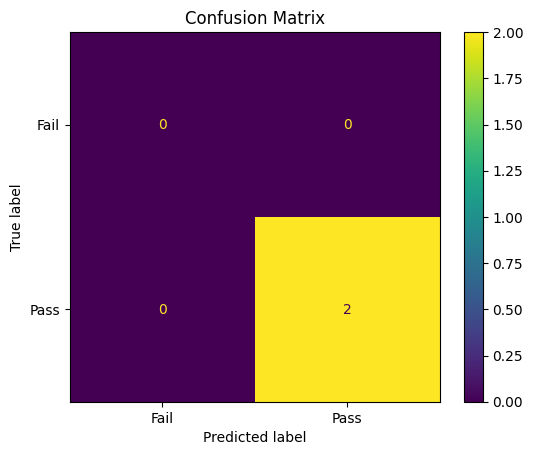

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred, labels=encoder.transform(encoder.classes_))

print("Confusion Matrix:")
print(cm)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

**Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = model_rf.predict(X_test)

print("Results: ")
print("Actual :", y_test)
print("Predicted :", y_pred_rf)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy : {accuracy_rf}")

precision_rf = precision_score(y_test, y_pred_rf)
print(f"Precision : {precision_rf}")

recall_rf = recall_score(y_test, y_pred_rf)
print(f"Recall : {recall_rf}")

f1_rf = f1_score(y_test, y_pred_rf)
print(f"F1 Score : {f1_rf}")

Results: 
Actual : [1 1]
Predicted : [1 1]
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0


Confusion Matrix:
[[0 0]
 [0 2]]


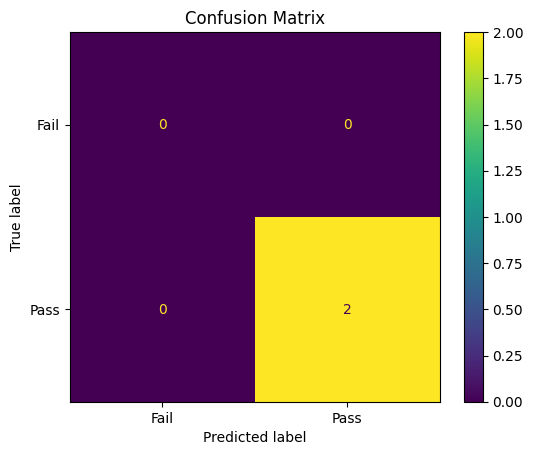

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=encoder.transform(encoder.classes_))

print("Confusion Matrix:")
print(cm_rf)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=encoder.classes_
)

disp_rf.plot()
plt.title("Confusion Matrix")
plt.show()